# IEEE-CIS Fraud Detection — Hyperparameter Tuning (LightGBM)

## Goal
Use Optuna (Bayesian optimisation) to find the best LightGBM hyperparameters.
Optimise for AUC-PR on the validation set — our primary metric.

## Why Optuna over GridSearch?
GridSearch tries every combination exhaustively — 5 values × 4 params = 625 runs.
Optuna learns from each trial which parameter regions are promising and samples there next.
50 smart trials beat 500 exhaustive ones.

## Parameters being tuned
| Parameter | Why |
|---|---|
| `num_leaves` | Controls tree complexity in leaf-wise growth |
| `max_depth` | Caps tree depth, works with num_leaves |
| `learning_rate` | Step size per tree — lower = better generalisation |
| `min_child_samples` | Min samples per leaf — important for sparse fraud patterns |
| `reg_lambda` | L2 regularisation — prevents overconfident leaf values |

In [1]:
import pandas as pd
import numpy as np
import optuna
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import average_precision_score
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

os.chdir('/Users/shaliqshukoor/fraud-risk-system')

# Load data
train_df = pd.read_parquet('data/processed/train_features.parquet')
val_df   = pd.read_parquet('data/processed/val_features.parquet')

with open('data/processed/feature_names.json') as f:
    feature_cols = json.load(f)

X_train = train_df[feature_cols]
y_train = train_df['isFraud']
X_val   = val_df[feature_cols]
y_val   = val_df['isFraud']

# Label encode remaining object columns
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col]   = le.transform(X_val[col].astype(str).map(
        lambda x: x if x in le.classes_ else le.classes_[0]
    ))

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')

/Users/shaliqshukoor/fraud-risk-system/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_train: (442905, 443)
X_val:   (147635, 443)


## Chapter 1 — Define the Objective Function

Optuna calls this function once per trial.
Each trial gets a different set of parameters suggested by Optuna.
The function returns AUC-PR — Optuna maximises this.

In [2]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def objective(trial):
    params = {
        'n_estimators': 1000,
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 31, 256),
        'max_depth':          trial.suggest_int('max_depth', 4, 10),
        'min_child_samples':  trial.suggest_int('min_child_samples', 20, 200),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'is_unbalance': True,
        'metric': 'average_precision',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[early_stopping(50, verbose=False), log_evaluation(-1)]
    )

    y_pred_proba = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_pred_proba)

print('Objective function defined.')
print('Each trial will train one LightGBM model and return its AUC-PR.')

Objective function defined.
Each trial will train one LightGBM model and return its AUC-PR.


## Chapter 2 — Run the Study

50 trials. Optuna will print the best AUC-PR found so far as it goes.
This will take ~20-40 minutes depending on your machine.

In [3]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest AUC-PR: {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

joblib.dump(study, 'models/optuna_study_lgbm.pkl')
print('\nStudy saved to models/optuna_study_lgbm.pkl (06_champion_challenger.ipynb and 07_final_model_training.ipynb reload it)')

Best trial: 13. Best value: 0.547216: 100%|██████████| 50/50 [45:12<00:00, 54.26s/it] 


Best AUC-PR: 0.5472
Best params:
  learning_rate: 0.0623709583523809
  num_leaves: 209
  max_depth: 10
  min_child_samples: 199
  reg_lambda: 0.07039038843905186

Study saved to models/optuna_study_lgbm.pkl (06_champion_challenger.ipynb and 07_final_model_training.ipynb reload it)


## Chapter 3 — Retrain with Best Params and Save

In [4]:
import mlflow
from sklearn.metrics import roc_auc_score, f1_score

mlflow.set_experiment('fraud-detection')

best_params = {
    **study.best_params,
    'n_estimators': 1000,
    'is_unbalance': True,
    'metric': 'average_precision',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

with mlflow.start_run(run_name='lightgbm_tuned'):
    mlflow.log_params(best_params)

    tuned_model = LGBMClassifier(**best_params)
    tuned_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[early_stopping(50), log_evaluation(100)]
    )

    y_pred_proba = tuned_model.predict_proba(X_val)[:, 1]
    y_pred       = (y_pred_proba >= 0.5).astype(int)

    auc_pr  = average_precision_score(y_val, y_pred_proba)
    auc_roc = roc_auc_score(y_val, y_pred_proba)
    f1      = f1_score(y_val, y_pred)

    mlflow.log_metric('auc_pr',  auc_pr)
    mlflow.log_metric('auc_roc', auc_roc)
    mlflow.log_metric('f1',      f1)

    joblib.dump(tuned_model, 'models/lightgbm_tuned.pkl')

    print(f'Tuned LightGBM Results:')
    print(f'  AUC-PR:  {auc_pr:.4f}  (baseline: 0.5265)')
    print(f'  AUC-ROC: {auc_roc:.4f}  (baseline: 0.9057)')
    print(f'  F1:      {f1:.4f}  (baseline: 0.3784)')
    print(f'  Best iteration: {tuned_model.best_iteration_}')
    print(f'Model saved to models/lightgbm_tuned.pkl')

Training until validation scores don't improve for 50 rounds
[100]	valid_0's average_precision: 0.499708
[200]	valid_0's average_precision: 0.525684
[300]	valid_0's average_precision: 0.53846
[400]	valid_0's average_precision: 0.541121
[500]	valid_0's average_precision: 0.544343
Early stopping, best iteration is:
[539]	valid_0's average_precision: 0.547216
Tuned LightGBM Results:
  AUC-PR:  0.5472  (baseline: 0.5265)
  AUC-ROC: 0.8996  (baseline: 0.9057)
  F1:      0.4817  (baseline: 0.3784)
  Best iteration: 539
Model saved to models/lightgbm_tuned.pkl
🏃 View run lightgbm_tuned at: https://germanywestcentral.api.azureml.ms/mlflow/v2.0/subscriptions/1462cf45-0a1d-4624-a94a-ce9949a6ffd4/resourceGroups/shaliq_study/providers/Microsoft.MachineLearningServices/workspaces/shaliq_demo/#/experiments/51a2010c-aa0f-4cbe-a06b-ae4cdfbda8ca/runs/6b5afc28-650e-45f6-a07f-c63cc0911195
🧪 View experiment at: https://germanywestcentral.api.azureml.ms/mlflow/v2.0/subscriptions/1462cf45-0a1d-4624-a94a-ce9

## Chapter 4 — Feature Selection via Importance (Gain)

Drop zero-importance features and retrain.
A simpler model is easier to explain to the business and faster in production.

Total features:           443
Zero importance features: 33
Non-zero features:        410


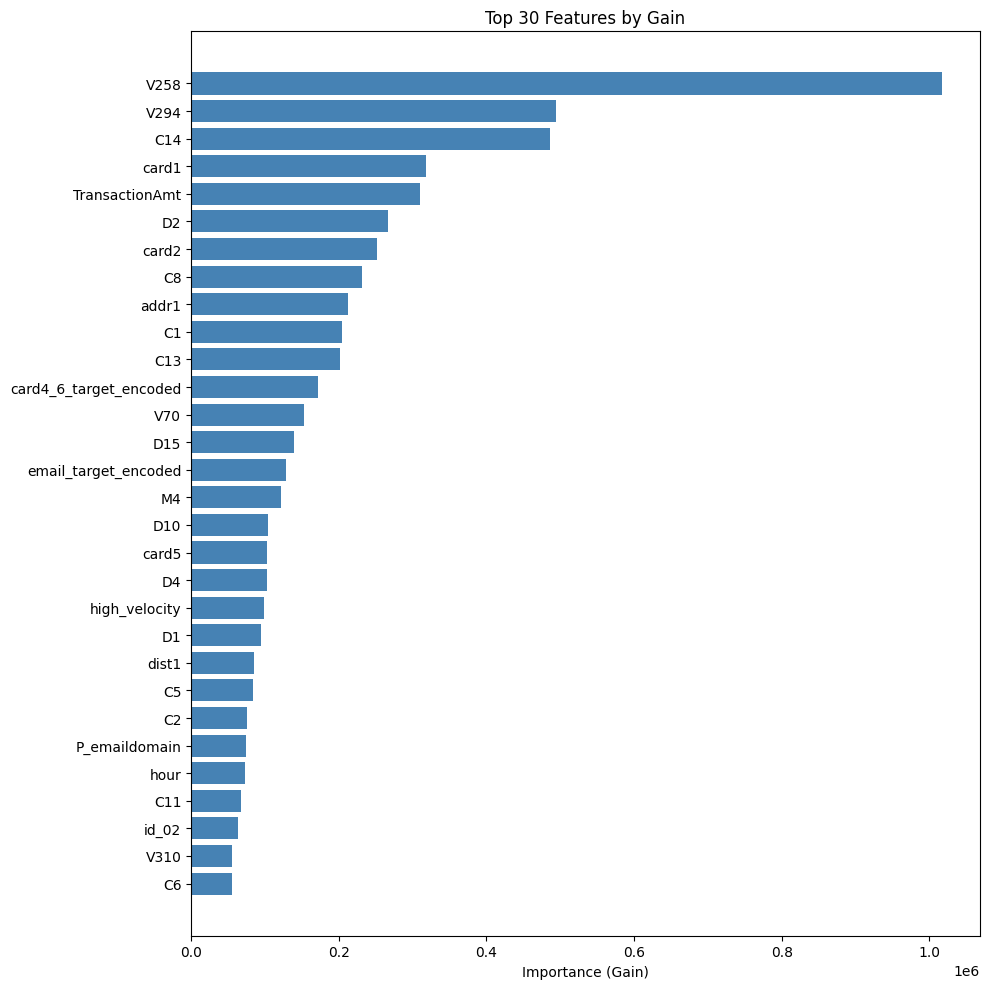

In [5]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': tuned_model.booster_.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

zero_importance    = importance_df[importance_df['importance'] == 0]
nonzero_importance = importance_df[importance_df['importance'] > 0]

print(f'Total features:           {len(importance_df)}')
print(f'Zero importance features: {len(zero_importance)}')
print(f'Non-zero features:        {len(nonzero_importance)}')

# Plot top 30
top30 = importance_df.head(30)
plt.figure(figsize=(10, 10))
plt.barh(top30['feature'][::-1], top30['importance'][::-1], color='steelblue')
plt.xlabel('Importance (Gain)')
plt.title('Top 30 Features by Gain')
plt.tight_layout()
plt.savefig('models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
selected_features = nonzero_importance['feature'].tolist()
print(f'Features kept:    {len(selected_features)} / {len(feature_cols)}')
print(f'Features dropped: {len(feature_cols) - len(selected_features)}')

X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]

best_params_sel = {
    **study.best_params,
    'n_estimators': 1000,
    'is_unbalance': True,
    'metric': 'average_precision',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

model_final = LGBMClassifier(**best_params_sel)
model_final.fit(
    X_train_sel, y_train,
    eval_set=[(X_val_sel, y_val)],
    callbacks=[early_stopping(50), log_evaluation(100)]
)

y_pred_proba = model_final.predict_proba(X_val_sel)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

auc_pr  = average_precision_score(y_val, y_pred_proba)
auc_roc = roc_auc_score(y_val, y_pred_proba)
f1      = f1_score(y_val, y_pred)

print(f'\n--- Results after feature selection ---')
print(f'AUC-PR:  {auc_pr:.4f}  (tuned full: 0.5518)')
print(f'AUC-ROC: {auc_roc:.4f}  (tuned full: 0.9008)')
print(f'F1:      {f1:.4f}  (tuned full: 0.4727)')

joblib.dump(model_final, 'models/lightgbm_final.pkl')
with open('data/processed/selected_feature_names.json', 'w') as f:
    json.dump(selected_features, f)

print(f'\nFinal model saved to models/lightgbm_final.pkl')
print(f'Selected features saved to data/processed/selected_feature_names.json')

Features kept:    410 / 443
Features dropped: 33
Training until validation scores don't improve for 50 rounds
[100]	valid_0's average_precision: 0.49943
[200]	valid_0's average_precision: 0.525489
[300]	valid_0's average_precision: 0.536006
[400]	valid_0's average_precision: 0.541302
[500]	valid_0's average_precision: 0.544707
[600]	valid_0's average_precision: 0.545708
Early stopping, best iteration is:
[569]	valid_0's average_precision: 0.546221

--- Results after feature selection ---
AUC-PR:  0.5462  (tuned full: 0.5518)
AUC-ROC: 0.8997  (tuned full: 0.9008)
F1:      0.4787  (tuned full: 0.4727)

Final model saved to models/lightgbm_final.pkl
Selected features saved to data/processed/selected_feature_names.json


In [7]:
top30

,feature,importance
309,V258,1.017627e+06
345,V294,4.948071e+05
27,C14,4.863720e+05
2,card1,3.184737e+05
0,TransactionAmt,3.105199e+05
29,D2,2.666125e+05
3,card2,2.514025e+05
21,C8,2.321001e+05
8,addr1,2.121315e+05
14,C1,2.042661e+05
